this code base is just for milestone 2


In [ ]:
!pip install -U transformers accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 90.0 MB/s eta 0:00:00
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0


In [ ]:
import pandas as pd
import numpy as np
import re
import nltk
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

from nltk.corpus import stopwords

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Conv1D, MaxPooling1D
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

Download NLTK Data


In [ ]:
nltk.download('stopwords')
from nltk.corpus import stopwords

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Load Dataset

In [ ]:
df = pd.read_csv(
    '/content/drive/MyDrive/archive/training.1600000.processed.noemoticon.csv',
    encoding='latin-1',
    header=None
)

df.columns = ['label', 'id', 'date', 'query', 'user', 'text']
df = df[['text', 'label']]
df = df[df['label'].isin([0, 4])]
df = df.sample(100000, random_state=42)  # use 100k for speed
# ✅ Convert labels PROPERLY
df = df[df['label'].isin([0, 4])]   # remove bad rows
df['label'] = df['label'].replace({0:0, 4:1})

# 🚨 CRITICAL LINE (YOU MISSED THIS)
y = df['label'].values.astype(np.int32)
print(df.shape) # Data Check
print(df['label'].value_counts())
print(df['label'].unique())

/tmp/ipykernel_3247/1495094687.py:1: DtypeWarning: Columns (0,1) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(


(100000, 2)
label
0    72923
1    27077
Name: count, dtype: int64
[0 1]


/tmp/ipykernel_3247/1495094687.py:13: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['label'] = df['label'].replace({0:0, 4:1})


Preprocessing

In [ ]:
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower()
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#', '', text)
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    words = text.split()
    words = [w for w in words if w not in stop_words]
    return " ".join(words)

df['clean_text'] = df['text'].apply(clean_text)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Tokenization + Padding

In [ ]:
tokenizer = Tokenizer(num_words=10000)
tokenizer.fit_on_texts(df['clean_text'])

X = tokenizer.texts_to_sequences(df['clean_text'])
X = pad_sequences(X, maxlen=100)

y = df['label']

BASELINE MODEL (LSTM)

In [ ]:
model_lstm = Sequential()
model_lstm.add(Embedding(input_dim=10000, output_dim=128, input_length=100))
model_lstm.add(LSTM(128))
model_lstm.add(Dropout(0.5))
model_lstm.add(Dense(1, activation='sigmoid'))

model_lstm.compile(loss='binary_crossentropy',
                   optimizer='adam',
                   metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


re_split data

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [ ]:
print("X dtype:", type(X), X.dtype)
print("y dtype:", type(y), y.dtype)

print("X_train dtype:", type(X_train), X_train.dtype)
print("y_train dtype:", type(y_train), y_train.dtype)

X dtype: <class 'numpy.ndarray'> int32
y dtype: <class 'pandas.core.series.Series'> int64
X_train dtype: <class 'numpy.ndarray'> int32
y_train dtype: <class 'pandas.core.series.Series'> int64


Train LSTM

In [ ]:
history_lstm = model_lstm.fit(
    X_train, y_train,
    epochs=3,
    batch_size=64,
    validation_data=(X_test, y_test)
)

Epoch 1/3
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 367s 289ms/step - accuracy: 0.7923 - loss: 0.4503 - val_accuracy: 0.8084 - val_loss: 0.4188
Epoch 2/3
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 346s 276ms/step - accuracy: 0.8299 - loss: 0.3794 - val_accuracy: 0.8066 - val_loss: 0.4221
Epoch 3/3
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 337s 270ms/step - accuracy: 0.8509 - loss: 0.3356 - val_accuracy: 0.8044 - val_loss: 0.4488


Evaluate LSTM

In [ ]:
loss, acc = model_lstm.evaluate(X_test, y_test)
print("LSTM Accuracy:", acc)

625/625 ━━━━━━━━━━━━━━━━━━━━ 37s 60ms/step - accuracy: 0.8044 - loss: 0.4488
LSTM Accuracy: 0.8043500185012817


HYBRID MODEL (CNN + LSTM)

In [ ]:
model_hybrid = Sequential()
model_hybrid.add(Embedding(10000, 128, input_length=100))
model_hybrid.add(Conv1D(64, 5, activation='relu'))
model_hybrid.add(MaxPooling1D(pool_size=2))
model_hybrid.add(LSTM(100))
model_hybrid.add(Dense(1, activation='sigmoid'))

model_hybrid.compile(loss='binary_crossentropy',
                     optimizer='adam',
                     metrics=['accuracy'])

Train Hybrid Model

In [ ]:
history_hybrid = model_hybrid.fit(
    X_train, y_train,
    epochs=3,
    batch_size=64,
    validation_data=(X_test, y_test)
)

Epoch 1/3
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 186s 144ms/step - accuracy: 0.7915 - loss: 0.4487 - val_accuracy: 0.8073 - val_loss: 0.4160
Epoch 2/3
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 181s 145ms/step - accuracy: 0.8384 - loss: 0.3636 - val_accuracy: 0.8054 - val_loss: 0.4302
Epoch 3/3
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 200s 144ms/step - accuracy: 0.8814 - loss: 0.2785 - val_accuracy: 0.7980 - val_loss: 0.4950


Evaluate Hybrid

In [ ]:
loss, acc = model_hybrid.evaluate(X_test, y_test)
print("Hybrid Model Accuracy:", acc)

625/625 ━━━━━━━━━━━━━━━━━━━━ 17s 27ms/step - accuracy: 0.7980 - loss: 0.4950
Hybrid Model Accuracy: 0.7979999780654907


SIMULATED DUNG BEETLE OPTIMIZATION

We optimize LSTM units + batch size

In [ ]:
best_acc = 0
best_params = {}

for units in [64, 128]:
    for batch in [32, 64]:
        model = Sequential()
        model.add(Embedding(10000, 128, input_length=100))
        model.add(LSTM(units))
        model.add(Dense(1, activation='sigmoid'))

        model.compile(loss='binary_crossentropy',
                      optimizer='adam',
                      metrics=['accuracy'])

        model.fit(X_train, y_train, epochs=2,
                  batch_size=batch, verbose=0)

        loss, acc = model.evaluate(X_test, y_test, verbose=0)

        if acc > best_acc:
            best_acc = acc
            best_params = {'units': units, 'batch': batch}

print("Best Accuracy:", best_acc)
print("Best Parameters:", best_params)

Best Accuracy: 0.8106499910354614
Best Parameters: {'units': 64, 'batch': 64}


Compare Results

In [ ]:
print("LSTM Accuracy:", model_lstm.evaluate(X_test, y_test)[1])
print("Hybrid Accuracy:", model_hybrid.evaluate(X_test, y_test)[1])
print("Optimized Accuracy:", best_acc)

625/625 ━━━━━━━━━━━━━━━━━━━━ 40s 65ms/step - accuracy: 0.8044 - loss: 0.4488
LSTM Accuracy: 0.8043500185012817
625/625 ━━━━━━━━━━━━━━━━━━━━ 13s 20ms/step - accuracy: 0.7980 - loss: 0.4950
Hybrid Accuracy: 0.7979999780654907
Optimized Accuracy: 0.8106499910354614


Save Model

In [ ]:
model_hybrid.save("final_model.h5")

Custom Prediction

In [ ]:
def predict_sentiment(text):
    text = clean_text(text)
    seq = tokenizer.texts_to_sequences([text])
    padded = pad_sequences(seq, maxlen=100)
    pred = model_hybrid.predict(padded)
    return "Positive" if pred > 0.5 else "Negative"

print(predict_sentiment("i hate you"))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
Negative


Plot Training Graph

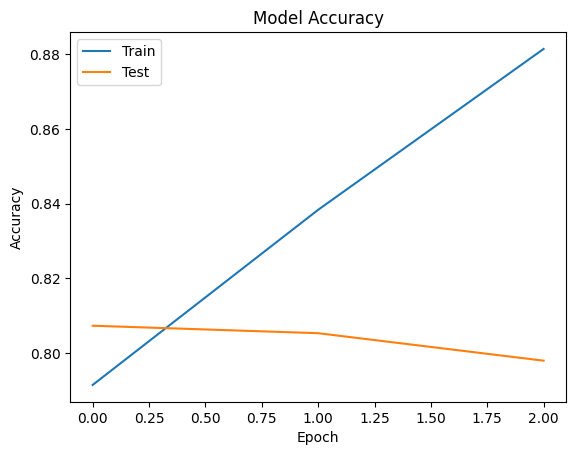

In [ ]:
plt.plot(history_hybrid.history['accuracy'])
plt.plot(history_hybrid.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Test'])
plt.show()